# Fraud Analysis in Card-Not-Present Transactions
**CloudWalk technical case — Martech Analyst** · Matheus

---

## 1. Context and Objective

A sample of 3,199 card-not-present (CNP) transactions from a single month was provided, with a flag indicating which ones ended in a fraud-related chargeback. The goal: identify suspicious behavior, explain the reasoning behind each conclusion, recommend preventive measures and design an anti-fraud solution.

Why this matters for an acquirer: in a CNP environment the fraud liability falls on the merchant side — and on the acquirer as guarantor when the merchant cannot cover it. Chargebacks are a direct cost line, and card networks start monitoring programs and fines above roughly 1% of chargeback rate.

### Method

Every finding in this notebook follows the same path: **hypothesis → evidence → action**. Each suspicion comes from how CNP fraud actually operates, becomes a testable prediction on the data, and ends with a proposed action. Hypotheses are stated up front (section 3) and tested one by one (section 4), including one that the data refuted.

**Tools:** SQL (DuckDB over pandas) for all exploration, seaborn for visualization, and an LLM layer for the review-agent prototype.

**On the use of AI:** this analysis was carried out by me with AI as an analytical partner — to speed up code, review logic and challenge hypotheses. The hypotheses, analytical decisions and conclusions are mine.

In [22]:
!pip install duckdb -q

In [23]:
import pandas as pd
import duckdb
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", context="notebook", font_scale=0.95)
CORAL, PURPLE, BLUE, GRAY = "#E24B4A", "#7C5CBF", "#378ADD", "#8A8A8A"

df = pd.read_csv("transactional-sample.csv")
df.head()

,transaction_id,merchant_id,user_id,card_number,transaction_date,transaction_amount,device_id,has_cbk
0,21320398,29744,97051,434505******9116,2019-12-01T23:16:32.812632,374.56,285475.0,False
1,21320399,92895,2708,444456******4210,2019-12-01T22:45:37.873639,734.87,497105.0,True
2,21320400,47759,14777,425850******7024,2019-12-01T22:22:43.021495,760.36,NaN,False
3,21320401,68657,69758,464296******3991,2019-12-01T21:59:19.797129,2556.13,NaN,True
4,21320402,54075,64367,650487******6116,2019-12-01T21:30:53.347051,55.36,860232.0,False


### Project architecture

The path from raw data to the proposed solution, generated by code for reproducibility.

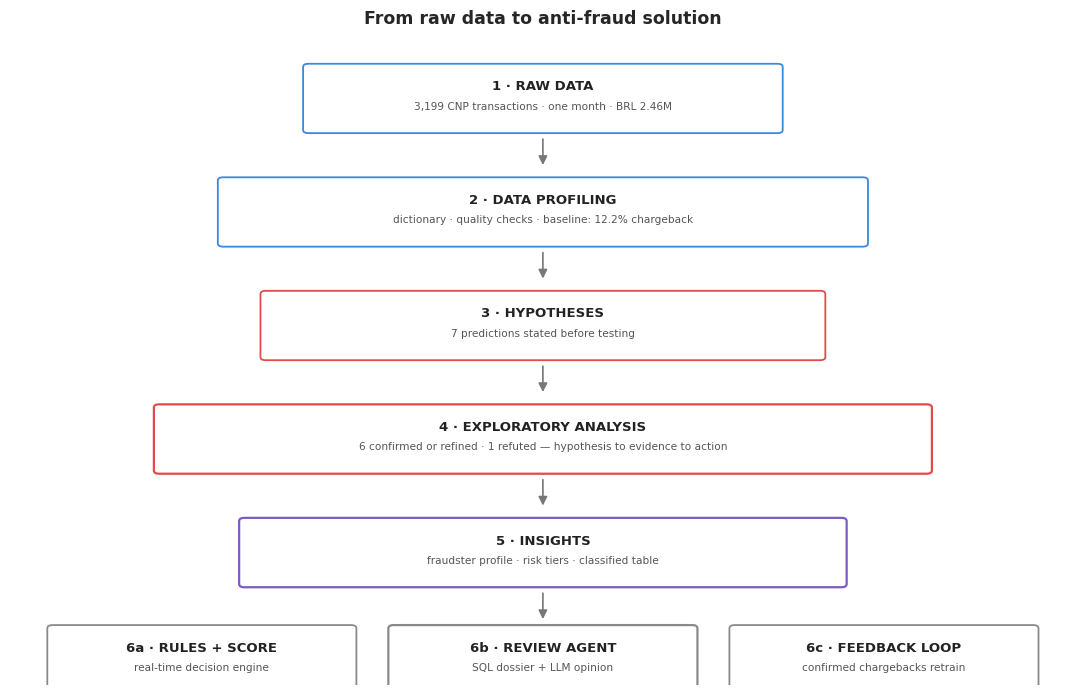

In [24]:
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

fig, ax = plt.subplots(figsize=(11, 7))
ax.set_xlim(0, 100); ax.set_ylim(0, 100); ax.axis("off"); ax.grid(False)

def box(x, y, w, h, title, sub, color, lw=1.3):
    ax.add_patch(FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.5",
                 facecolor="white", edgecolor=color, linewidth=lw))
    ax.text(x+w/2, y+h-2.0, title, ha="center", va="top", fontsize=9.5, fontweight="bold", color="#222")
    ax.text(x+w/2, y+h-5.4, sub, ha="center", va="top", fontsize=7.6, color="#555")

def arrow(x1, y1, x2, y2):
    ax.add_patch(FancyArrowPatch((x1, y1), (x2, y2), arrowstyle="-|>", mutation_scale=13, color="#777", lw=1.2))

box(28, 88, 44, 10, "1 · RAW DATA", "3,199 CNP transactions · one month · BRL 2.46M", BLUE)
arrow(50, 87, 50, 82)
box(20, 70, 60, 10, "2 · DATA PROFILING", "dictionary · quality checks · baseline: 12.2% chargeback", BLUE)
arrow(50, 69, 50, 64)
box(24, 52, 52, 10, "3 · HYPOTHESES", "7 predictions stated before testing", CORAL)
arrow(50, 51, 50, 46)
box(14, 34, 72, 10, "4 · EXPLORATORY ANALYSIS", "6 confirmed or refined · 1 refuted — hypothesis to evidence to action", CORAL, 1.6)
arrow(50, 33, 50, 28)
box(22, 16, 56, 10, "5 · INSIGHTS", "fraudster profile · risk tiers · classified table", PURPLE, 1.6)
arrow(50, 15, 50, 10)
box(4, 0, 28, 9, "6a · RULES + SCORE", "real-time decision engine", GRAY)
box(36, 0, 28, 9, "6b · REVIEW AGENT", "SQL dossier + LLM opinion", GRAY, 1.6)
box(68, 0, 28, 9, "6c · FEEDBACK LOOP", "confirmed chargebacks retrain", GRAY)

fig.suptitle("From raw data to anti-fraud solution", fontsize=12.5, fontweight="bold", y=0.99)
plt.tight_layout(); plt.show()

## 2. About the Data

| Column | Meaning |
|---|---|
| `transaction_id` | unique transaction identifier |
| `merchant_id` | the seller |
| `user_id` | the buyer's account on the platform |
| `card_number` | masked card — first 6 digits (BIN, identifies the issuer) plus last digits |
| `transaction_date` | timestamp |
| `transaction_amount` | amount in BRL |
| `device_id` | **the buyer's device** (phone or computer). All transactions are card-not-present, so there is no terminal involved — the device is the fingerprint of whoever is buying |
| `has_cbk` | **the label**: did the transaction end in a fraud-related chargeback? Every hypothesis is judged against this column |

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3199 entries, 0 to 3198
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   transaction_id      3199 non-null   int64  
 1   merchant_id         3199 non-null   int64  
 2   user_id             3199 non-null   int64  
 3   card_number         3199 non-null   object 
 4   transaction_date    3199 non-null   object 
 5   transaction_amount  3199 non-null   float64
 6   device_id           2369 non-null   float64
 7   has_cbk             3199 non-null   bool   
dtypes: bool(1), float64(2), int64(3), object(2)
memory usage: 178.2+ KB


3,199 transactions covering one month (Nov 1 to Dec 1, 2019). One column is incomplete: `device_id` has 2,369 values — **830 transactions (26%) arrived with no device identification**. Rather than treating this as dirty data to discard, it became the first hypothesis to test (section 4.1).

### 2.1 Automated quality checks

Beyond manual profiling, a battery of automated checks — the seed of the monitoring that would run on every load in production, with alerts. Each check declares an expectation about the data; a failure triggers investigation, not panic.

In [26]:
def run_quality_checks(df):
    """Data quality battery. In production each ALERT would trigger a notification."""
    checks = []
    def check(name, passed, detail):
        checks.append({"check": name, "status": "OK" if passed else "ALERT", "detail": detail})

    dup = df["transaction_id"].duplicated().sum()
    check("transaction_id is unique", dup == 0, f"{dup} duplicates")

    nulls = df[["transaction_id","user_id","transaction_amount","transaction_date","has_cbk"]].isna().sum().sum()
    check("no nulls in critical fields", nulls == 0, f"{nulls} nulls found")

    dev_null = df["device_id"].isna().mean()
    check("device_id coverage >= 90%", dev_null <= 0.10, f"{dev_null:.1%} missing (alert threshold: 10%)")

    neg = (df["transaction_amount"] <= 0).sum()
    check("amounts are positive", neg == 0, f"{neg} transactions with amount <= 0")

    dates = pd.to_datetime(df["transaction_date"])
    days, span = dates.dt.date.nunique(), (dates.max() - dates.min()).days + 1
    check("date continuity", days == span, f"{days} days with data over a {span}-day span")

    masked = df["card_number"].str.match(r"^\d{6}\*{6}\d{2,5}$")
    check("card mask format", masked.all(), f"{(~masked).sum()} outside the expected pattern")

    return pd.DataFrame(checks)

run_quality_checks(df)

,check,status,detail
0,transaction_id is unique,OK,0 duplicates
1,no nulls in critical fields,OK,0 nulls found
2,device_id coverage >= 90%,ALERT,25.9% missing (alert threshold: 10%)
3,amounts are positive,OK,0 transactions with amount <= 0
4,date continuity,OK,31 days with data over a 31-day span
5,card mask format,OK,0 outside the expected pattern


One legitimate alert: `device_id` coverage at 74%, far below the threshold — investigated in section 4.1 and turned into an instrumentation recommendation.

Worth recording how this check evolved: its first version assumed every card has 16 digits and flagged 39 "violations". Investigation showed they were legitimate 14 to 17-digit cards (Amex, Diners and similar) with a *below-average* chargeback rate — **the alert was right to fire and wrong in its premise**, and the rule was refined. That is data governance in miniature: stated expectation → alert → investigation → better rule.

### 2.2 Baseline — the size of the problem

Before hunting for patterns, the ruler: what is the portfolio's overall chargeback rate? Every group analysed later is compared against it.

In [27]:
duckdb.query("""
    SELECT
      COUNT(*)                                                            AS transactions,
      ROUND(SUM(transaction_amount), 2)                                   AS total_amount,
      ROUND(AVG(has_cbk::INT), 4)                                         AS chargeback_rate,
      ROUND(SUM(CASE WHEN has_cbk THEN transaction_amount ELSE 0 END), 2) AS amount_charged_back,
      MIN(transaction_date)                                               AS period_start,
      MAX(transaction_date)                                               AS period_end
    FROM df
""").df()

,transactions,total_amount,chargeback_rate,amount_charged_back,period_start,period_end
0,3199,2456233.48,0.1222,568346.62,2019-11-01T01:27:15.811098,2019-12-01T23:16:32.812632


**The portfolio is on fire.** A **12.2% chargeback rate** — card networks start monitoring programs and fines at around 1%, so this portfolio runs **twelve times above** that threshold. In monetary terms it is worse: **BRL 568k disputed out of BRL 2.46M processed (23%)** — nearly a quarter of the money comes back, which already suggests fraud concentrates on high tickets (confirmed in 4.5).

Note on the label: a chargeback takes weeks to surface, because the cardholder only disputes after seeing the statement. The 12.2% is therefore a **floor**, not the final number — fraud committed in the last days of the sample had no time to mature into a dispute.

## 3. Hypotheses

Stated before testing. Each one comes from a known mechanism of CNP fraud and predicts a measurable trace in the data.

| # | Hypothesis | Expected trace if true |
|---|---|---|
| H1 | Fraudsters hide by suppressing device identification | Transactions without `device_id` show a **higher** chargeback rate |
| H2 | Card testing: someone runs a list of stolen cards from one place | A device or account with **many distinct cards** and extreme chargeback |
| H3 | Fraud is run by few professional operators, not many opportunists | A handful of accounts concentrate a **disproportionate share** of chargebacks |
| H4 | Fraudsters insist on the same card until it is exhausted | Cards used **repeatedly**, in short intervals, concentrate chargebacks |
| H5 | Fraudsters buy liquidity — expensive, resellable goods | Chargeback rate **rises with amount** |
| H6 | Fraud prefers late-night hours, when monitoring is thinner | Higher chargeback rate between midnight and 6am |
| H7 | Some merchants are in collusion — shell stores cashing out stolen cards | Merchants with extreme chargeback and **very few distinct buyers** |

The order below follows the order in which the investigation actually happened, because the sequence of questions explains the answers.

## 4. Exploratory Analysis

### 4.1 The missing device — a hypothesis refuted (H1)

I started where the data looked broken. `device_id` was empty in 26% of the rows, which first read as a quality problem to fix. The second reading was more suspicious: if the device is the fingerprint of whoever buys in a CNP environment, maybe the fraudster was erasing his own trace. That is H1, and it predicts a higher chargeback rate in the group without a device.

In [28]:
duckdb.query("""
    SELECT
      CASE WHEN device_id IS NULL THEN 'no device_id' ELSE 'device tracked' END AS group_name,
      COUNT(*)                    AS transactions,
      ROUND(AVG(has_cbk::INT), 3) AS chargeback_rate
    FROM df
    GROUP BY group_name
""").df()

,group_name,transactions,chargeback_rate
0,device tracked,2369,0.137
1,no device_id,830,0.081


**The data refutes H1.** Transactions without a device show a **lower** chargeback rate (8.1% vs 13.7%). This is not camouflage and not random noise: it points to a collection gap — most likely a sales channel that does not capture the identifier.

I keep the refuted hypothesis in the notebook for two reasons. First, honesty: a hypothesis discarded with method is also a result. Second, the gap remains a real problem — **the anti-fraud engine is blind to the device in one out of every four transactions**. Fixing that instrumentation is a concrete recommendation, and it is exactly the kind of tracking and validation work this role is about.

**Action:** treat `device_id` coverage as a monitored metric with a target of 100% on payment events, and audit each channel's collection (section 7.2).

### 4.2 One device, many cards (H2)

If the fraudster does not hide in missing data, he is visible in some excess. Grouping by device asks a simple question: **is any single device being used with more cards than a real person could hold?**

Two SQL clauses do different jobs here: `WHERE` filters **rows** before grouping, `HAVING` filters **groups** after they are formed — "more than one distinct card" only exists once the group exists.

In [29]:
duckdb.query("""
    SELECT
      device_id,
      COUNT(*)                          AS transactions,
      COUNT(DISTINCT card_number)       AS distinct_cards,
      COUNT(DISTINCT user_id)           AS distinct_accounts,
      ROUND(SUM(transaction_amount), 2) AS total_amount,
      ROUND(AVG(has_cbk::INT), 3)       AS chargeback_rate
    FROM df
    WHERE device_id IS NOT NULL
    GROUP BY device_id
    HAVING COUNT(DISTINCT card_number) > 1
    ORDER BY distinct_cards DESC, transactions DESC
    LIMIT 15
""").df()

,device_id,transactions,distinct_cards,distinct_accounts,total_amount,chargeback_rate
0,563499.0,22,22,1,17335.51,0.864
1,342890.0,19,19,1,11802.88,0.789
2,101848.0,17,15,1,35497.93,0.882
3,438940.0,14,10,1,30200.22,0.929
4,547440.0,13,10,1,39195.13,0.923
5,542535.0,7,7,1,3747.88,0.857
6,223682.0,7,7,1,4254.19,0.571
7,262327.0,6,6,1,11682.44,0.667
8,960729.0,6,6,1,21840.69,1.000
9,203134.0,5,5,1,1648.67,0.000


The top device ran **22 transactions with 22 distinct cards** and an 86% chargeback rate. My first hypothesis for this was innocent — it could be a store, or someone buying stock with several corporate cards. The data itself ruled that out: **19 of those 22 transactions ended in chargeback**. No legitimate store accumulates 86% disputes.

### 4.3 The pivot — the account is the signature

A column I had not focused on changed the direction of the investigation: **`distinct_accounts` is 1 for every suspicious device**. If each dirty device belongs to a single account, then the account is the more fundamental entity — the device is disposable, the login is not. Same query, different entity.

In [30]:
duckdb.query("""
    SELECT
      user_id,
      COUNT(*)                          AS transactions,
      COUNT(DISTINCT card_number)       AS distinct_cards,
      COUNT(DISTINCT device_id)         AS distinct_devices,
      ROUND(SUM(transaction_amount), 2) AS total_amount,
      ROUND(AVG(has_cbk::INT), 3)       AS chargeback_rate
    FROM df
    GROUP BY user_id
    HAVING COUNT(DISTINCT card_number) >= 5
    ORDER BY distinct_cards DESC
    LIMIT 15
""").df()

,user_id,transactions,distinct_cards,distinct_devices,total_amount,chargeback_rate
0,11750,31,31,4,17816.26,0.806
1,91637,22,22,1,17335.51,0.864
2,79054,17,15,1,35497.93,0.882
3,96025,14,10,1,30200.22,0.929
4,78262,13,10,1,39195.13,0.923
5,7695,7,7,1,4254.19,0.571
6,17929,6,6,1,21840.69,1.000
7,34548,6,6,2,1889.77,0.000
8,67519,6,6,1,11682.44,0.667
9,7725,7,5,2,10822.94,1.000


**H2 confirmed, and the largest operator in the sample appears whole:** account `11750` — **31 transactions, 31 distinct cards, spread across 4 devices, 81% chargeback**. In the device view he dissolved into four small piles; in the account view he shows up complete. The lesson generalises: the fraudster escapes one lens by discarding what is cheap to discard, so the entity to group by is the one he cannot easily replace.

There are also accounts with the same shape (5+ cards) and **zero chargebacks** — genuinely ambiguous: either legitimate customers with several cards of their own, or fraud whose disputes have not matured yet.

**Action:** a graduated rule on distinct cards accumulated per account — up to 2, normal flow; 3 to 4, monitoring; 5 to 7, **3DS challenge** on every new card; 8 or more, decline and lock for review. The ladder protects revenue in ambiguous cases (a legitimate customer confirms the challenge in their banking app in seconds; a fraudster does not have the victim's phone) and would have stopped account `11750` at the eighth card — dozens of frauds earlier.

> **3DS (3-D Secure)** is the extra verification in which the issuer challenges the buyer — "confirm this purchase in your banking app" or a one-time code. In many cases an authenticated transaction also shifts fraud liability from the merchant to the issuer.

### 4.4 The hammered card (H4)

The two lenses above look at the device and the account. The card deserves its own: if a fraudster insists on the same stolen card until it is exhausted, cards that repeat — especially in short intervals — should concentrate chargebacks.

In [31]:
duckdb.query("""
    WITH card_usage AS (
        SELECT card_number, COUNT(*) AS uses FROM df GROUP BY card_number
    )
    SELECT
      CASE WHEN u.uses = 1 THEN 'used once'
           WHEN u.uses <= 3 THEN '2-3 uses'
           ELSE '4+ uses' END        AS usage_group,
      COUNT(*)                       AS transactions,
      ROUND(AVG(t.has_cbk::INT), 3)  AS chargeback_rate
    FROM df t
    JOIN card_usage u ON t.card_number = u.card_number
    GROUP BY usage_group
    ORDER BY MIN(u.uses)
""").df()

,usage_group,transactions,chargeback_rate
0,used once,2733,0.073
1,2-3 uses,376,0.375
2,4+ uses,90,0.556


In [32]:
# Does the interval between uses matter more than the count?
duckdb.query("""
    WITH ordered AS (
        SELECT card_number, has_cbk,
               transaction_date::TIMESTAMP AS ts,
               LAG(transaction_date::TIMESTAMP) OVER (
                   PARTITION BY card_number ORDER BY transaction_date::TIMESTAMP) AS previous_ts
        FROM df
    )
    SELECT
      CASE WHEN date_diff('minute', previous_ts, ts) <= 60
           THEN 'reused within 60 min' ELSE 'reused later' END AS pace,
      COUNT(*)                    AS transactions,
      ROUND(AVG(has_cbk::INT), 3) AS chargeback_rate
    FROM ordered
    WHERE previous_ts IS NOT NULL
    GROUP BY pace
""").df()

,pace,transactions,chargeback_rate
0,reused later,138,0.297
1,reused within 60 min,136,0.603


**H4 confirmed, with a sharper edge than expected.** A card used once carries a 7.3% chargeback rate; with 2 to 3 uses, 37.5%; with four or more, **55.6%**. And the interval discriminates even more than the count: when the same card comes back **within 60 minutes**, the rate reaches **60.3%**, against 29.7% for spaced reuse. A legitimate card appears once in this sample; the more it repeats, and the faster, the higher the risk.

**Action:** from the third use of the same card, add points to the risk score; **reuse within one hour triggers an immediate 3DS challenge**. The signal also feeds the review agent's dossier (6.5).

**Declared limitation:** this sample contains **approved transactions only**. The strongest trace of this pattern — declined attempts in sequence — would require the authorization result. A decline is data, not noise (see 7.2).

### 4.5 Amount and hour (H5, H6)

Two behavioural hypotheses tested together, because both act as context multipliers rather than standalone verdicts.

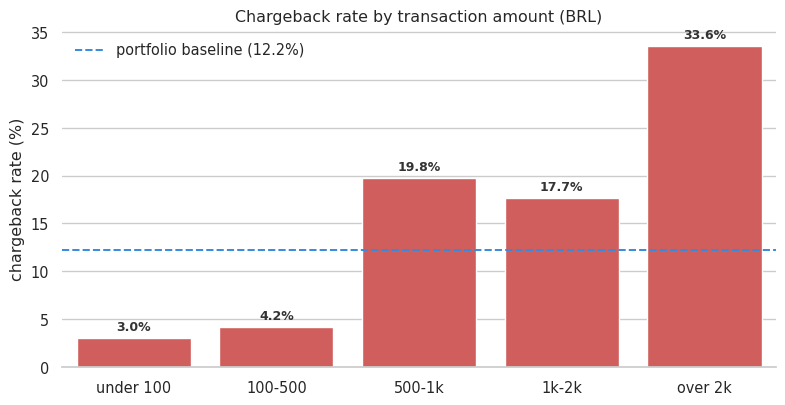

In [33]:
bands = duckdb.query("""
    SELECT
      CASE
        WHEN transaction_amount < 100  THEN 'under 100'
        WHEN transaction_amount < 500  THEN '100-500'
        WHEN transaction_amount < 1000 THEN '500-1k'
        WHEN transaction_amount < 2000 THEN '1k-2k'
        ELSE 'over 2k' END           AS amount_band,
      COUNT(*)                       AS transactions,
      ROUND(AVG(has_cbk::INT)*100, 1) AS chargeback_rate
    FROM df
    GROUP BY amount_band
    ORDER BY MIN(transaction_amount)
""").df()

fig, ax = plt.subplots(figsize=(8, 4.2))
sns.barplot(data=bands, x="amount_band", y="chargeback_rate", color=CORAL, ax=ax)
ax.axhline(12.2, color=BLUE, ls="--", lw=1.4, label="portfolio baseline (12.2%)")
for i, v in enumerate(bands["chargeback_rate"]):
    ax.text(i, v + 0.8, f"{v}%", ha="center", fontsize=9, fontweight="bold", color="#333")
ax.set(title="Chargeback rate by transaction amount (BRL)", xlabel="", ylabel="chargeback rate (%)")
ax.legend(frameon=False); sns.despine(left=True)
plt.tight_layout(); plt.show()

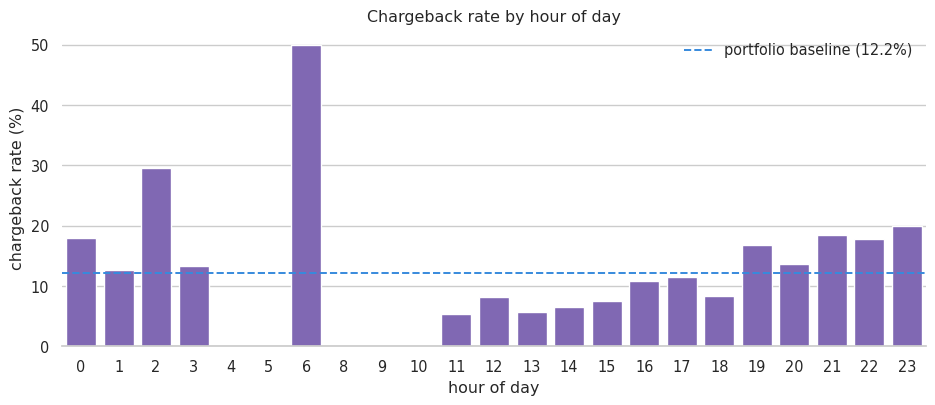

In [34]:
hours = duckdb.query("""
    SELECT
      EXTRACT(hour FROM transaction_date::TIMESTAMP) AS hour,
      COUNT(*)                        AS transactions,
      ROUND(AVG(has_cbk::INT)*100, 1) AS chargeback_rate
    FROM df
    GROUP BY hour
    ORDER BY hour
""").df()

fig, ax = plt.subplots(figsize=(9.5, 4.2))
sns.barplot(data=hours, x="hour", y="chargeback_rate", color=PURPLE, ax=ax)
ax.axhline(12.2, color=BLUE, ls="--", lw=1.4, label="portfolio baseline (12.2%)")
ax.set(title="Chargeback rate by hour of day", xlabel="hour of day", ylabel="chargeback rate (%)")
ax.legend(frameon=False); sns.despine(left=True)
plt.tight_layout(); plt.show()

**H5 confirmed:** up to BRL 500 the rate stays at 3 to 4%; **above BRL 2,000 it jumps to 33.6%** — one in three transactions. Fraudulent transactions average BRL 1,454 against BRL 672 for clean ones. The fraudster buys liquidity, not convenience.

**H6 confirmed:** late night (midnight to 6am) runs at **17.3%** against **4.5%** in the morning — almost four times. Evening hours are also above baseline.

**Action:** neither signal should decline a transaction on its own — legitimate late-night and high-value purchases exist. Both should carry weight in the score and **lower the challenge threshold**: above roughly BRL 1,000 combined with any second signal (new account, late night, card newly added), trigger 3DS.

### 4.6 Recurrence — who comes back (H3, refined)

My original hypothesis here was about bursts: several purchases within minutes. The test refuted the narrow version and revealed something broader. Measuring "minutes since the previous purchase" only covers accounts with two or more purchases — and *that whole group* was rotten, burst or no burst. So the question became simpler: **first purchase versus every purchase after it**.

The tool is a **window function**: `ROW_NUMBER() OVER (PARTITION BY user_id ORDER BY ...)` numbers each account's purchases in time order without collapsing rows — `GROUP BY` crushes rows into a summary, a window keeps every row and writes the summary beside it.

In [35]:
duckdb.query("""
    WITH ordered AS (
        SELECT
          user_id, has_cbk,
          ROW_NUMBER() OVER (PARTITION BY user_id ORDER BY transaction_date::TIMESTAMP) AS purchase_number
        FROM df
    )
    SELECT
      CASE WHEN purchase_number = 1 THEN 'first purchase'
           ELSE 'second onwards (same month)' END AS purchase_type,
      COUNT(*)                    AS transactions,
      ROUND(AVG(has_cbk::INT), 3) AS chargeback_rate
    FROM ordered
    GROUP BY purchase_type
    ORDER BY purchase_type DESC
""").df()

,purchase_type,transactions,chargeback_rate
0,second onwards (same month),495,0.525
1,first purchase,2704,0.048


**The gap is eleven-fold:** the first purchase of an account carries **4.8%** chargeback; **from the second onwards, 52.5%**. In this sample the legitimate customer buys once a month, while the fraudster operates in series — consistent with account `11750`, whose 31 purchases all sit in this second group.

**Action:** progressive scoring per account rather than a block — from the second transaction in the month, the account's score rises; combined with a new card or a high amount, it triggers a challenge. This is the finding that most needs calibration with a longer history: over twelve months, long-term recurrence is probably a sign of *loyalty*, and what would remain toxic is **compressed** recurrence from a recently created account (see 7.2 on account age).

### 4.7 Following the trail — the merchant side (H7)

Account `11750` left one more clue: **23 of his 31 purchases went to the same merchant**. That turned the lens to the other side of the counter.

In [36]:
duckdb.query("""
    SELECT
      merchant_id,
      COUNT(*)                          AS transactions,
      COUNT(DISTINCT user_id)           AS distinct_buyers,
      ROUND(SUM(transaction_amount), 2) AS total_amount,
      ROUND(AVG(has_cbk::INT), 3)       AS chargeback_rate
    FROM df
    GROUP BY merchant_id
    HAVING COUNT(*) >= 10 AND AVG(has_cbk::INT) >= 0.5
    ORDER BY chargeback_rate DESC, total_amount DESC
""").df()

,merchant_id,transactions,distinct_buyers,total_amount,chargeback_rate
0,1308,15,2,34517.94,1.000
1,73271,10,3,14577.57,1.000
2,44927,11,3,9218.62,1.000
3,29214,10,3,5831.58,0.900
4,77130,15,2,6249.81,0.867
5,4705,22,1,17335.51,0.864
6,55854,11,3,5518.01,0.818
7,65330,10,3,32673.95,0.800
8,91972,14,11,39754.74,0.786
9,53041,19,8,21079.55,0.737


**H7 confirmed.** Merchants with 10 to 15 sales and **100% chargeback**, several of them selling to **two or three buyers only**. The signature is unmistakable: many sales, almost no distinct customers, total disputes.

The mechanics explain the incentive. In ordinary fraud the merchant is a victim — he sold, shipped and lost. Here, merchant and buyer are the same operation: a shell store is opened so that stolen cards can be "spent" in it, the money lands in the store's account, and the operator disappears before the disputes arrive weeks later. The loss was designed from the start to land on the acquirer, who answers as guarantor.

**Action:** continuous monitoring of chargeback rate per merchant with an automatic **settlement hold** — retaining pending payouts is the acquirer's strongest lever, because it closes the cash-out window the scheme depends on. Buyer concentration (few accounts responsible for most of a merchant's sales) becomes an additional signal at onboarding and in monitoring.

## 5. Insights

### 5.1 The fraudster profile

Putting the seven tests together, the composite that emerges is **not the diffuse opportunist — it is the professional operator**:

- **Operates through dedicated accounts.** He keeps the login and changes devices, which makes the account (not the device) the stable signature — up to 31 distinct cards on one account across 4 devices.
- **Carries lists of stolen cards** and hammers them: four or more uses of the same card push the chargeback rate to 55.6%, and reuse within an hour to 60.3%.
- **Buys liquidity.** Above BRL 2,000 the rate triples against the baseline.
- **Prefers late night.** 17.3% between midnight and 6am against 4.5% in the morning.
- **Acts in series.** First purchase 4.8%, second onwards 52.5%.
- **At the top of the chain, collusion.** Shell merchants with 100% chargeback and two or three buyers, monetising cards with the loss aimed at the acquirer.
- **What he does *not* do:** hide behind missing tracking. The group without `device_id` is cleaner than average — that gap is instrumentation, not evasion.

### 5.2 Risk tiers — turning the profile into policy

Each criterion below comes from one of the findings above, applied at account level.

- **A — clean:** no signal. Normal flow, zero friction (protecting experience and revenue).
- **B — block:** convicted by the data — 8+ distinct cards, or 3+ chargebacks, or a rate at or above 50% with more than one purchase.
- **C — watchlist:** the shape without the conviction — 3 to 7 cards, recurrence within the month, or a single chargeback. Stricter bar: **3DS challenge on every transaction**; a failed challenge or a second signal declines it. The challenge is what separates, inside tier C, the honest multi-card customer from the fraudster whose disputes have not arrived yet.

In [37]:
tiers = duckdb.query("""
    WITH accounts AS (
        SELECT user_id,
               COUNT(*)                    AS tx,
               COUNT(DISTINCT card_number) AS cards,
               AVG(has_cbk::INT)           AS cbk_rate,
               SUM(has_cbk::INT)           AS cbks,
               SUM(transaction_amount)     AS amount
        FROM df GROUP BY user_id
    )
    SELECT
      CASE
        WHEN cards >= 8 OR cbks >= 3 OR (cbk_rate >= 0.5 AND tx >= 2) THEN 'B - block'
        WHEN cards BETWEEN 3 AND 7 OR tx >= 3 OR cbks >= 1            THEN 'C - watchlist'
        ELSE 'A - clean'
      END                                        AS risk_tier,
      COUNT(*)                                   AS accounts,
      SUM(tx)                                    AS transactions,
      ROUND(SUM(cbks) * 1.0 / SUM(tx), 3)        AS chargeback_rate,
      ROUND(100.0 * SUM(cbks) / (SELECT SUM(has_cbk::INT) FROM df), 1) AS pct_of_all_chargebacks,
      ROUND(SUM(amount), 0)                      AS total_amount
    FROM accounts
    GROUP BY risk_tier
    ORDER BY risk_tier
""").df()
tiers

,risk_tier,accounts,transactions,chargeback_rate,pct_of_all_chargebacks,total_amount
0,A - clean,2526,2647.0,0.000,0.0,1755320.0
1,B - block,86,379.0,0.855,82.9,478325.0
2,C - watchlist,92,173.0,0.387,17.1,222589.0


**H3 confirmed, and the operational news is good.** **93% of the accounts are clean — a 0% chargeback rate — and should feel no friction at all.** At the other end, **86 accounts (3%) concentrate 83% of every chargeback in the portfolio**, and 92 accounts sit in the watchlist. Note the validation: tier A came out at exactly zero chargebacks, meaning the criteria captured all 391 disputes — no fraudster was left classified as clean.

Thresholds are calibratable: in production each cut would be tuned by measuring fraud captured against legitimate revenue lost. What the design defends is the logic — conviction, suspicion, clearance.

### 5.3 Materialising the decision

The segmentation is only useful if it is queryable. The pattern: aggregate at account level in a CTE, apply the classification, then return the label to transaction level with a `LEFT JOIN`. In production this would run on a schedule as the reference table — the engine reads the tier in real time, analysts investigate, and a dashboard tracks accounts migrating between tiers.

In [38]:
classified = duckdb.query("""
    WITH accounts AS (
        SELECT user_id,
               COUNT(*)                    AS tx,
               COUNT(DISTINCT card_number) AS cards,
               AVG(has_cbk::INT)           AS cbk_rate,
               SUM(has_cbk::INT)           AS cbks
        FROM df GROUP BY user_id
    ),
    tiered AS (
        SELECT user_id, tx AS account_tx, cards AS account_cards,
               ROUND(cbk_rate, 3) AS account_cbk_rate,
               CASE
                 WHEN cards >= 8 OR cbks >= 3 OR (cbk_rate >= 0.5 AND tx >= 2) THEN 'B - block'
                 WHEN cards BETWEEN 3 AND 7 OR tx >= 3 OR cbks >= 1            THEN 'C - watchlist'
                 ELSE 'A - clean'
               END AS risk_tier
        FROM accounts
    )
    SELECT t.transaction_id, t.user_id, ti.risk_tier,
           t.transaction_amount, t.transaction_date, t.merchant_id, t.has_cbk,
           ti.account_cards, ti.account_tx, ti.account_cbk_rate
    FROM df t
    LEFT JOIN tiered ti ON t.user_id = ti.user_id
    ORDER BY ti.risk_tier DESC, ti.account_cards DESC, t.transaction_date
""").df()

classified.to_csv("classified_transactions.csv", index=False)
print(classified["risk_tier"].value_counts(), "\n")
classified.head(10)

risk_tier
A - clean        2647
B - block         379
C - watchlist     173
Name: count, dtype: int64 



,transaction_id,user_id,risk_tier,transaction_amount,transaction_date,merchant_id,has_cbk,account_cards,account_tx,account_cbk_rate
0,21323127,34548,C - watchlist,241.10,2019-11-12T21:47:21.506873,33192,False,6,6,0.0
1,21323058,34548,C - watchlist,30.37,2019-11-15T15:42:57.017945,33192,False,6,6,0.0
2,21322795,34548,C - watchlist,204.43,2019-11-18T18:55:00.623996,33192,False,6,6,0.0
3,21322578,34548,C - watchlist,455.27,2019-11-21T15:42:08.588252,33192,False,6,6,0.0
4,21321908,34548,C - watchlist,325.54,2019-11-23T17:22:18.582230,33192,False,6,6,0.0
5,21321630,34548,C - watchlist,633.06,2019-11-26T11:34:02.112442,33192,False,6,6,0.0
6,21322818,67245,C - watchlist,20.40,2019-11-18T17:26:28.550985,704,False,5,5,0.0
7,21321157,67245,C - watchlist,1257.51,2019-11-28T23:55:39.206551,704,False,5,5,0.0
8,21321146,67245,C - watchlist,1010.73,2019-11-29T00:19:53.781982,704,False,5,5,0.0
9,21321004,67245,C - watchlist,966.10,2019-11-29T16:31:39.121491,704,False,5,5,0.0


# 6. Executive Report

## 6.1 Executive summary

A portfolio of 3,199 CNP transactions shows a **12.2% chargeback rate — twelve times the ~1% threshold** where card networks begin monitoring and fines — with **BRL 568k disputed, 23% of all money processed**.

The loss is not diffuse. **86 accounts (3% of the base) account for 83% of every chargeback**, while 93% of the portfolio is entirely clean. The dominant pattern is professional card testing: dedicated accounts running lists of stolen cards (up to 31 distinct cards on a single account), buying high-value goods, late at night, in series — and, at the top of the chain, shell merchants with 100% chargeback selling to two or three "buyers", designed so the loss lands on the acquirer.

The response has three horizons: an immediate surgical action on the identified accounts and merchants; a set of real-time rules derived from the findings; and structural fixes in data collection and merchant monitoring.

## 6.2 Diagnosis

**Concentration, not epidemic.** 0.7% of accounts hold 41% of chargebacks; 3% hold 83%. This makes targeted action viable and cheap.

**The account is the unit of fraud.** Devices are disposable (the largest operator used four); the login is where behaviour accumulates. Detection anchored on the device alone dissolves the pattern.

**The signals compound.** No single attribute convicts: amount, hour and recurrence are multipliers, while distinct-card count and merchant concentration are near-verdicts. That is why the design combines rules with a score.

**One in four transactions is invisible to device-based logic.** The `device_id` gap (26%) is a collection failure, not evasion — but it blinds the engine either way.

## 6.3 Recommendations

**Immediate (this week)**
1. Review and block the 86 tier-B accounts, starting with the 20 that concentrate 41% of chargebacks.
2. Suspend settlement for merchants matching the collusion pattern (extreme chargeback with very few distinct buyers) and open investigation — retaining pending payouts is what closes the cash-out window.

**Prevention rules (real-time engine)**
3. Graduated ladder on distinct cards per account: 3-4 monitor, 5-7 challenge with 3DS, 8+ decline and lock.
4. 3DS challenge for transactions above roughly BRL 1,000 combined with any second signal — new account, late night, newly added card.
5. Card-level velocity: third use of the same card adds score; reuse within 60 minutes triggers a challenge.
6. Progressive recurrence scoring per account from the second transaction in the month.

**Structural**
7. Fix `device_id` instrumentation (26% loss) and standardise collection across channels, with coverage as a monitored metric and alerting on degradation.
8. Continuous chargeback monitoring per merchant with automatic settlement hold — this protects the acquirer both from the guarantor role and from network fines (threshold ~1%; the portfolio sits at 12.2%).

**Calibration principle.** A false negative costs the chargeback; a false positive costs the sale, the MDR and possibly the customer. That asymmetry is why the architecture prioritises the **challenge** over the decline in ambiguous cases — and why 93% of the portfolio must keep feeling no friction whatsoever. Fraud control is, in that sense, a retention problem: every legitimate customer wrongly blocked is churn, and a well-calibrated engine is what protects the lifetime value of the honest base.

## 6.4 Anti-fraud solution

**Layer 1 — deterministic rules (milliseconds).** The rules above plus block lists for account, device and card. Transparent, auditable, cheap. They settle the obvious cases: approve the clean, decline the blatant.

**Layer 2 — risk score (model).** For the grey zone, a model trained on the `has_cbk` label using the features this analysis validated: distinct cards per account, recurrence in period, amount relative to history, hour, device presence, card usage count, merchant's historical rate. Output 0-100: low approves, medium **challenges with 3DS**, high declines and routes to review.

**Layer 3 — feedback loop.** Every confirmed chargeback feeds block lists and model retraining, with drift monitoring — fraud changes tactics once blocked, so the system has to change with it.

Risk tiers act as pre-computed memory that all three layers read: tier B declines at layer 1, tier C starts with points against it and a lower challenge threshold, tier A passes unimpeded.

## 6.5 Review agent — prototype

For cases routed to manual review, an agent in two layers:

1. **Deterministic dossier (SQL).** Given a transaction, it pulls the history of the account, the card and the merchant, applies the validated signals and proposes a decision by rules. Every fact comes from this layer — **the language model never calculates or invents a number**.
2. **Written opinion (LLM).** The dossier is handed to a model that drafts the case summary, the suggested decision and what additional evidence would change it.

**Why the human still decides.** The model only sees what the dossier contains — it has no access to the context outside the data (the customer's phone call, the campaign that explains a spike, the commercial history). The cost of erring is asymmetric and situational, and weighing it is a business judgement. And accountability cannot be delegated to a model: when a decision suspends a merchant's livelihood, someone has to sign it, and an audit requires the facts to be verifiable. The agent does not replace the analyst — it multiplies him, turning a fifteen-minute review into thirty seconds.

**Natural evolution:** decomposing this into specialised sub-agents (signal enrichment, risk assessment, drafting) would let each step be tested and versioned separately. A single agent is kept here because it is sufficient for this volume and simpler to audit; decomposition earns its complexity when the steps need different models, prompts or latencies.

In [39]:
import json

def build_dossier(transaction_id, df=df):
    """Collects the risk signals of one transaction into a structured dossier (deterministic layer)."""
    tx = duckdb.query(f"SELECT * FROM df WHERE transaction_id = {transaction_id}").df()
    if tx.empty:
        return None
    tx = tx.iloc[0]

    account = duckdb.query(f"""
        SELECT COUNT(*) AS transactions,
               COUNT(DISTINCT card_number) AS distinct_cards,
               COUNT(DISTINCT device_id)   AS distinct_devices,
               ROUND(AVG(has_cbk::INT), 3) AS historical_cbk_rate,
               ROUND(AVG(transaction_amount), 2) AS avg_ticket
        FROM df WHERE user_id = {tx['user_id']}
    """).df().iloc[0]

    merchant = duckdb.query(f"""
        SELECT COUNT(*) AS transactions,
               COUNT(DISTINCT user_id) AS distinct_buyers,
               ROUND(AVG(has_cbk::INT), 3) AS cbk_rate
        FROM df WHERE merchant_id = {tx['merchant_id']}
    """).df().iloc[0]

    card = duckdb.query(f"""
        SELECT COUNT(*) AS uses, ROUND(AVG(has_cbk::INT), 3) AS cbk_rate
        FROM df WHERE card_number = '{tx['card_number']}'
    """).df().iloc[0]

    hour = pd.to_datetime(tx["transaction_date"]).hour
    signals = []
    if account["distinct_cards"] >= 5:
        signals.append(f"account holds {int(account['distinct_cards'])} distinct cards (ladder: 5-7 challenge, 8+ decline)")
    if account["historical_cbk_rate"] >= 0.5:
        signals.append(f"account historical chargeback rate {account['historical_cbk_rate']:.0%}")
    if account["transactions"] >= 2:
        signals.append(f"recurrent account this month ({int(account['transactions'])} transactions; 52.5% cbk rate in this group)")
    if tx["transaction_amount"] >= 2000:
        signals.append(f"high amount ({tx['transaction_amount']:.2f} BRL; the 2k+ band runs at 33.6% cbk)")
    elif tx["transaction_amount"] >= 1000:
        signals.append(f"elevated amount ({tx['transaction_amount']:.2f} BRL)")
    if hour < 6:
        signals.append(f"late night ({hour}h; 17.3% cbk vs 4.5% in the morning)")
    if pd.isna(tx["device_id"]):
        signals.append("no device_id (instrumentation gap: engine blind to the device)")
    if card["uses"] >= 3:
        signals.append(f"card already used {int(card['uses'])} times (3+ uses: 55.6% cbk rate)")
    if merchant["cbk_rate"] >= 0.5 and merchant["transactions"] >= 5:
        signals.append(f"critical merchant (cbk rate {merchant['cbk_rate']:.0%} over {int(merchant['transactions'])} transactions)")
    if merchant["transactions"] >= 10 and merchant["distinct_buyers"] <= 3:
        signals.append(f"concentrated merchant ({int(merchant['transactions'])} sales to only {int(merchant['distinct_buyers'])} buyers — collusion pattern)")

    if account["distinct_cards"] >= 8 or (merchant["cbk_rate"] >= 0.8 and merchant["transactions"] >= 10):
        decision = "DECLINE"
    elif len(signals) >= 2:
        decision = "CHALLENGE (3DS)"
    elif len(signals) == 1:
        decision = "APPROVE with monitoring"
    else:
        decision = "APPROVE"

    return {
        "transaction": {"id": int(tx["transaction_id"]), "amount_brl": float(tx["transaction_amount"]),
                        "hour": int(hour), "user_id": int(tx["user_id"]), "merchant_id": int(tx["merchant_id"])},
        "account_history": {k: float(v) for k, v in account.items()},
        "merchant_history": {k: float(v) for k, v in merchant.items()},
        "card_history": {k: float(v) for k, v in card.items()},
        "signals_triggered": signals,
        "rule_based_decision": decision,
    }

In [40]:
# Demo 1 — a transaction from the largest operator in the sample (account 11750)
suspicious_tx = duckdb.query("""
    SELECT transaction_id FROM df WHERE user_id = 11750
    ORDER BY transaction_date DESC LIMIT 1
""").df().iloc[0, 0]

dossier = build_dossier(suspicious_tx)
print(json.dumps(dossier, indent=2))

{
  "transaction": {
    "id": 21320460,
    "amount_brl": 687.57,
    "hour": 16,
    "user_id": 11750,
    "merchant_id": 66876
  },
  "account_history": {
    "transactions": 31.0,
    "distinct_cards": 31.0,
    "distinct_devices": 4.0,
    "historical_cbk_rate": 0.806,
    "avg_ticket": 574.72
  },
  "merchant_history": {
    "transactions": 8.0,
    "distinct_buyers": 1.0,
    "cbk_rate": 0.875
  },
  "card_history": {
    "uses": 1.0,
    "cbk_rate": 1.0
  },
  "signals_triggered": [
    "account holds 31 distinct cards (ladder: 5-7 challenge, 8+ decline)",
    "account historical chargeback rate 81%",
    "recurrent account this month (31 transactions; 52.5% cbk rate in this group)",
    "critical merchant (cbk rate 88% over 8 transactions)"
  ],
  "rule_based_decision": "DECLINE"
}


In [41]:
# Demo 2 — a clean-profile transaction, for contrast
clean_tx = duckdb.query("""
    SELECT transaction_id FROM df
    WHERE transaction_amount < 100 AND NOT has_cbk
    LIMIT 1
""").df().iloc[0, 0]

clean_dossier = build_dossier(clean_tx)
print("Signals:", clean_dossier["signals_triggered"])
print("Decision:", clean_dossier["rule_based_decision"])

Signals: []
Decision: APPROVE


The LLM layer below drafts the opinion from the dossier. The key is that the prompt restricts the model to the facts it was given. The API key is read from the Colab secrets vault, so no credential is stored in this file — the architecture is vendor-agnostic: the same pattern works with any provider by changing the endpoint.

In [42]:
import requests
from google.colab import userdata  # add a secret named GROQ_API_KEY (console.groq.com)

GROQ_API_KEY = userdata.get("GROQ_API_KEY")

prompt = f"""You are a review-support agent for an acquirer's anti-fraud team.
Based EXCLUSIVELY on the JSON dossier below (do not invent numbers or facts),
write a short opinion for the human analyst with:
1. A summary of the case in up to 3 lines;
2. The suggested decision (approve / challenge with 3DS / decline), justified by the two strongest signals in order of severity;
3. One line on what would change your mind — be specific about the evidence you would request.

DOSSIER:
{json.dumps(dossier, indent=2)}
"""

response = requests.post(
    "https://api.groq.com/openai/v1/chat/completions",
    headers={"Authorization": f"Bearer {GROQ_API_KEY}"},
    json={
        "model": "openai/gpt-oss-120b",  # models get deprecated: check console.groq.com/docs/models
        "messages": [{"role": "user", "content": prompt}],
        "temperature": 0.2,
    },
)
response.raise_for_status()
print(response.json()["choices"][0]["message"]["content"])

**Summary:**  
- Cardholder 11750 is using a single‑use card that has already been linked to 31 different cards, far above the 8‑card decline threshold.  
- Both the account (81% historic chargeback rate) and the merchant (88% chargeback rate) exhibit extreme chargeback histories.

**Suggested decision:** **DECLINE** – the most severe signals are (1) the account’s 31 distinct‑card usage (exceeds the “decline” ladder) and (2) the account’s 81 % historical chargeback rate, indicating a pattern of fraud.

**What would change my mind:** Presentation of a recent, successful 3‑DS authentication or verified proof of legitimate card ownership that reduces the chargeback risk to below industry‑acceptable levels.


## 6.6 Expected impact

- **Blocking tier B removes 83% of current chargebacks** on the identified base, with no friction added to the 93% clean portfolio.
- **Settlement holds on colluding merchants** cap the exposure the acquirer carries as guarantor, and cut the cash-out incentive for shell stores.
- **The graduated ladder** would have stopped the largest operator at his eighth card — 23 frauds earlier.
- **Fixing `device_id` collection** restores visibility on a quarter of the traffic, improving every device-based rule and the score.

**Metrics to steer by:** portfolio chargeback rate (target below 1%), approval rate (protecting revenue), challenge completion rate (implicit false-positive proxy), and average manual review time.

# 7. Appendix

## 7.1 The payments industry

**Money flow, information flow and the main players.**

A card payment involves five actors: the **cardholder**, the **merchant**, the **acquirer** (which onboards the merchant and connects it to the network — CloudWalk's role), the **card network** (the rails and rulebook connecting acquirers to banks; it does not hold the money) and the **issuer** (the cardholder's bank). Two flows run in opposite directions at different speeds. **Information** moves in seconds: the authorization request starts at the checkout or acquirer, passes through the network and reaches the issuer — the only party that can decide, because it is the only one who knows the cardholder's limit, balance and card status; the answer returns along the same path. **Money** moves in days, the other way: issuer → network → acquirer → merchant, each link deducting its fee. The total deduction from the merchant is the **MDR**, an acquirer's main revenue line. The key point: **an approval is not a payment, it is a promise from the issuer** — the whole system is a chain of promises, and fraud is a promise breaking.

**Acquirer, sub-acquirer and payment gateway.**

The criterion that separates them is **where the money passes**. The **acquirer** is licensed to settle: it onboards merchants, carries risk before the network, and receives and passes on funds. The **gateway** is purely technical: it carries card data from the checkout to the acquirer, charges a per-transaction fee, **never touches the money and takes no risk** — with a gateway only the information flow gains an extra leg, while the money flow is unchanged. The **sub-acquirer** presents itself as the merchant to the chain: it holds its own contract with an acquirer, **receives the sales proceeds in its own account** and passes them to the end sellers, charging more and **absorbing their risk** — the money flow gains an extra stop, making settlement slower and more expensive at the end. Because the end sellers are invisible to the rest of the chain (the cardholder's statement shows the sub-acquirer's name) and onboarding is lighter, sub-acquirers are a preferred entry point for fraudsters.

**Chargebacks, how they differ from cancellations, and their link to fraud in acquiring.**

A **cancellation** is the friendly reversal, initiated at the store: the customer asks, the merchant agrees and refunds. A **chargeback** is when the cardholder bypasses the store and disputes directly with the issuer; the issuer refunds the customer and **pulls the money back through the chain by force** — the merchant is notified afterwards and starts out having lost it, with the right to present evidence in a dispute. The link to fraud in acquiring: in a **CNP** environment the fraud liability sits on the merchant side — he loses the amount, the goods already shipped, and pays a chargeback fee; **if the merchant fails or disappears, the acquirer pays as guarantor**, which makes fraud a direct hit to its cash. Not every chargeback is card fraud: there is **true fraud** (a third party used the card), **commercial dispute** (goods not delivered or defective) and **friendly fraud** (the cardholder disputes a purchase they actually made — often because they do not recognise the name on the statement). Networks monitor the **chargeback ratio** (disputes ÷ sales): above roughly 1%, merchants and acquirers enter monitoring programmes with fines. So an acquirer has two reasons to fight fraud: the loss and the penalty.

**What an anti-fraud system is and how an acquirer uses it.**

It is the system that evaluates each transaction **before authorization**, combining **deterministic rules** (for example, declining several attempts from the same card within minutes) with a **risk score** (a model weighing dozens of signals into a fraud probability), and choosing between three outcomes: **approve**, **challenge** (request further proof — 3DS, one-time code, manual review; the legitimate customer confirms in their banking app in seconds, the fraudster does not have the victim's phone) or **decline**. An acquirer uses it at three moments: at **onboarding** (KYC — keeping shell merchants out before they exist), **during the transaction** (the real-time engine, in milliseconds) and **afterwards** (monitoring the portfolio's chargeback ratio and suspending degraded merchants). The central trade-off calibrates everything: a **false negative** costs the chargeback, a **false positive** costs the sale, the MDR and possibly the customer — a good anti-fraud system is not the one that blocks the most, it is the one that finds the balance.

## 7.2 Data that would strengthen the analysis

All signals in this analysis are behavioural and indirect. The additions below are ordered by how much they would change the conclusions.

**Cardholder identity (hashed).** The most decisive gap. A hashed national ID (CPF) on both the account and the card would answer the question directly — *is the cardholder the account owner?* — characterising third-party card use **on the very first transaction**, without waiting weeks for a chargeback. Hashing preserves privacy: it allows comparison without exposing the underlying value. Practical caveat worth stating: the acquirer holds the account owner's identity from onboarding, but the cardholder's identity sits with the issuer — the mechanism that answers this in real life is precisely issuer authentication (3DS).

**Location and IP.** One of the strongest signals in CNP. Not just the coordinates but the *nature* of the connection (datacenter, VPN, proxy — a fraudster rarely operates from a home line), the distance between the IP and the registered address, and impossible-travel checks (the same card used in distant cities minutes apart). Applied to this sample it would settle an open question: were account `11750`'s four devices in the same place (one person with four handsets) or scattered (a ring sharing one login)?

**Account age.** On its own it says little — a new account is not a fraudulent account. Crossed with the chargeback analysis it becomes powerful: it separates the two populations that section 4.6 conflates. "Second purchase this month" from a five-year-old account is loyalty; the same behaviour from an account created three days ago is the compressed recurrence of an operation. This is the variable that would let the recurrence rule be calibrated without punishing genuine repeat customers.

**Authorization result, including declines.** This sample holds approved transactions only. Declined attempts in sequence are the live trace of card testing — a decline is data, not noise.

**Chargeback reason code and date.** The code separates true fraud from commercial disputes and friendly fraud; the date measures the label's maturation delay and lets us estimate fraud not yet reported.

**Shipping address.** Many different cards delivering to the same address is an operation's signature — it would close the case on the section 4.3 finding.

**Merchant onboarding data.** For the collusion finding: age of the company, and whether the merchant's settlement bank account belongs to the same person as the buying accounts. That does not suggest collusion — it proves it.

**Product category (MCC) and cart contents.** Explains the amount finding: electronics and gift cards are liquidity, services are not.

**Session telemetry.** Time at checkout, autofill versus manually typed card, typing attempts — distinguishes a human from a scripted series.

**BIN enrichment.** Free with the data at hand: the first six digits identify issuer, country and product type (prepaid, corporate), each with its own risk profile.

### Turning the wish list into a tracking spec

Listing desired data is the first step; specifying **how it would be captured** is the second. Naming convention `object_action` in `snake_case`, typed and required properties validated at collection, and the same event available across all destinations (product analytics, engagement, anti-fraud).

| Event | Fires when | Key properties |
|---|---|---|
| `checkout_started` | buyer opens the payment | `session_id`, `device_id`, `ip`, `ip_type`, `merchant_id` |
| `payment_attempted` | card data submitted | `amount`, `card_bin`, `card_last4`, `device_id`, `account_holder_hash`, `card_holder_hash`, `account_age_days` |
| `payment_declined` | issuer or engine declines | `decline_reason`, `decline_source` |
| `payment_authorized` | approval | `authorization_code`, `latency_ms` |
| `challenge_requested` / `challenge_completed` | 3DS triggered / resolved | `challenge_type`, `result` — measures friction and implicit false positives |
| `chargeback_received` | dispute arrives | `reason_code`, `days_since_transaction` |

Governance over the spec: a missing required property rejects the event at collection; an anomalous drop in any event's volume raises an alert (tracking broken by a deploy is the leading cause of data drift); `device_id` presence on payment events is an explicit target of 100% (currently 74%).

## 7.3 Declared limitations

**One month of data.** No seasonality, and the recurrence rule (4.6) would need calibration against a longer history — over twelve months, long-term recurrence is likely a loyalty signal, and only compressed recurrence from young accounts would remain toxic.

**The label matures late.** A chargeback arrives weeks after the transaction, so 12.2% is a floor and transactions near the end of the sample are under-labelled.

**The card mask can collapse distinct cards.** Six hidden digits mean two different cards could share the same masked string, so `COUNT(DISTINCT card_number)` **undercounts, never overcounts** — the 31 cards on account `11750` are a minimum, not a maximum.

**Approved transactions only.** Declines are absent, which limits the card-testing analysis to its post-approval trace.